# 🏠 Airbnb Listings — Full Data Science Pipeline
### Data Cleaning · EDA · ML Classification · Feature Importance · Business Insights
---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42
DATA_PATH = 'listings.csv'
print('✅ Imports OK')

✅ Imports OK


---
## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv("listings.csv")
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (36445, 85)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,https://www.airbnb.com/rooms/2595,20260213082241,2026-02-14,city scrape,Skylit Studio Oasis | Midtown Manhattan Sanctuary,Prime Midtown | Spacious 500 Sq Ft | Pyramid S...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2845,...,4.8,4.81,4.40,NaN,NaN,3,3,0,0,0.24
1,6848,https://www.airbnb.com/rooms/6848,20260213082241,2026-02-14,previous scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.8,4.69,4.59,NaN,NaN,1,1,0,0,0.97
2,6872,https://www.airbnb.com/rooms/6872,20260213082241,2026-02-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.0,5.00,5.00,NaN,NaN,2,0,2,0,0.04


In [3]:
# Overview of dtypes and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36445 entries, 0 to 36444
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36445 non-null  int64  
 1   listing_url                                   36445 non-null  object 
 2   scrape_id                                     36445 non-null  int64  
 3   last_scraped                                  36445 non-null  object 
 4   source                                        36445 non-null  object 
 5   name                                          36443 non-null  object 
 6   description                                   34952 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   36445 non-null  object 
 9   host_id                                       36445 non-null 

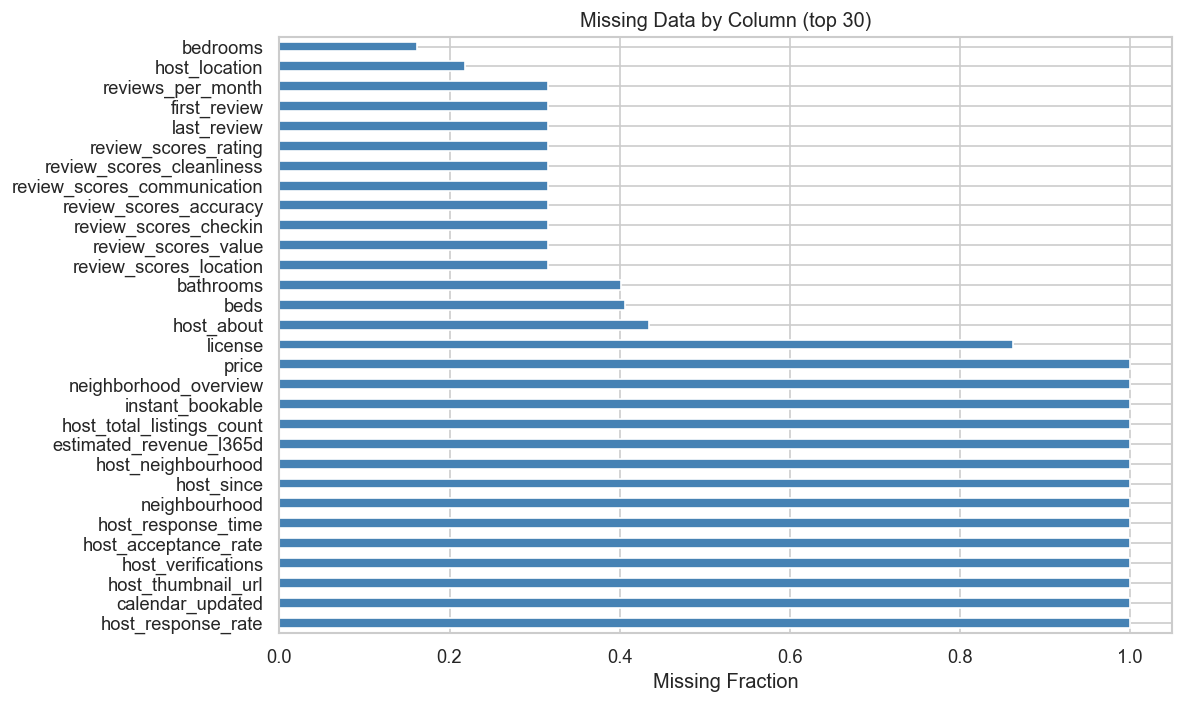

Columns with >50% missing: 15


In [4]:
# Missing value heatmap (top 30 columns by missingness)
missing = df_raw.isnull().mean().sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(10, 6))
missing[missing > 0].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing Fraction')
ax.set_title('Missing Data by Column (top 30)')
plt.tight_layout()
plt.show()
print(f'Columns with >50% missing: {(missing > 0.5).sum()}')

---
## 2. Data Cleaning

In [5]:
df = df_raw.copy()

# ── Drop columns that are entirely null or pure metadata ──────────────────
drop_cols = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
    'description', 'neighborhood_overview', 'picture_url',
    'host_url', 'host_profile_url', 'host_thumbnail_url', 'host_picture_url',
    'host_about', 'host_verifications', 'calendar_updated',
    'calendar_last_scraped', 'first_review', 'last_review',
    'license', 'amenities', 'bathrooms_text', 'neighbourhood',
    'host_neighbourhood', 'neighbourhood_group_cleansed',
    # columns that are all NaN in this dataset
    'price', 'estimated_revenue_l365d', 'host_since',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'host_total_listings_count', 'instant_bookable',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'has_availability',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'After dropping metadata/null cols: {df.shape}')

After dropping metadata/null cols: (36445, 49)


In [6]:
# ── Numeric cleaning ──────────────────────────────────────────────────────
num_cols = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'reviews_per_month',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'number_of_reviews', 'number_of_reviews_ltm',
    'number_of_reviews_l30d', 'availability_30', 'availability_60',
    'availability_90', 'availability_365', 'availability_eoy',
    'calculated_host_listings_count', 'host_listings_count',
    'estimated_occupancy_l365d',
    'hosts_time_as_user_years', 'hosts_time_as_host_years',
]
num_cols = [c for c in num_cols if c in df.columns]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute numeric with median
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print('Numeric columns cleaned & imputed with median.')

Numeric columns cleaned & imputed with median.


In [7]:
# ── Categorical cleaning ──────────────────────────────────────────────────
cat_cols = ['room_type', 'property_type', 'neighbourhood_cleansed']
cat_cols = [c for c in cat_cols if c in df.columns]

for col in cat_cols:
    df[col] = df[col].fillna('Unknown').str.strip()

# Collapse rare property types into 'Other'
top_props = df['property_type'].value_counts().nlargest(10).index
df['property_type'] = df['property_type'].where(
    df['property_type'].isin(top_props), 'Other'
)

# Collapse rare neighbourhoods (keep top 20)
top_hoods = df['neighbourhood_cleansed'].value_counts().nlargest(20).index
df['neighbourhood_cleansed'] = df['neighbourhood_cleansed'].where(
    df['neighbourhood_cleansed'].isin(top_hoods), 'Other'
)

print('Categorical columns cleaned.')

Categorical columns cleaned.


In [8]:
# ── Remove extreme outliers in key numeric cols ───────────────────────────
def cap_outliers(series, lower=0.01, upper=0.99):
    lo, hi = series.quantile([lower, upper])
    return series.clip(lo, hi)

for col in ['minimum_nights', 'maximum_nights', 'accommodates', 'beds', 'bedrooms']:
    if col in df.columns:
        df[col] = cap_outliers(df[col])

print(f'Final cleaned shape: {df.shape}')
df.head(3)

Final cleaned shape: (36445, 49)


,id,host_id,host_profile_id,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_listings_count,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,2845,1.462506e+18,Jennifer,17.0,5.0,15.0,1.0,"Woodstock, NY",7.0,...,4.63,4.77,4.8,4.81,4.40,3,3,0,0,0.24
1,6848,15991,1.462507e+18,Allen,16.0,9.0,15.0,1.0,"New York, NY",1.0,...,4.85,4.85,4.8,4.69,4.59,1,1,0,0,0.97
2,6872,16104,1.462507e+18,Kae,16.0,9.0,15.0,1.0,"New York, NY",2.0,...,5.00,5.00,5.0,5.00,5.00,2,0,2,0,0.04


In [9]:
# ── Save cleaned CSV ──────────────────────────────────────────────────────
df.to_csv('listings_cleaned.csv', index=False)
print('✅ Saved → listings_cleaned.csv')

✅ Saved → listings_cleaned.csv


---
## 3. Exploratory Data Analysis (EDA)

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,36445.0,NaN,NaN,NaN,504161483468969856.0,576889384000658944.0,2595.0,21959695.0,52241459.0,1029753759407075584.0,1619352090929639936.0
host_id,36445.0,NaN,NaN,NaN,181982463.270106,202506086.168404,1678.0,18876264.0,92974704.0,326084746.0,744548738.0
host_profile_id,35917.0,NaN,NaN,NaN,1466893507034179328.0,10357078408473736.0,1462506270716056832.0,1462852132562845952.0,1465484328095784448.0,1469252708271343872.0,1619085778832602368.0
host_name,35917,8206,Blueground,1210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,36445.0,NaN,NaN,NaN,8.376183,3.725093,0.0,6.0,9.0,11.0,17.0
hosts_time_as_user_months,35917.0,NaN,NaN,NaN,5.394465,3.387506,0.0,2.0,6.0,8.0,11.0
hosts_time_as_host_years,36445.0,NaN,NaN,NaN,6.815475,3.650935,0.0,4.0,7.0,10.0,15.0
hosts_time_as_host_months,35917.0,NaN,NaN,NaN,4.995434,3.430849,0.0,2.0,5.0,8.0,11.0
host_location,28477,994,"New York, NY",21451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_listings_count,36445.0,NaN,NaN,NaN,277.618576,1086.99455,1.0,1.0,2.0,11.0,5600.0


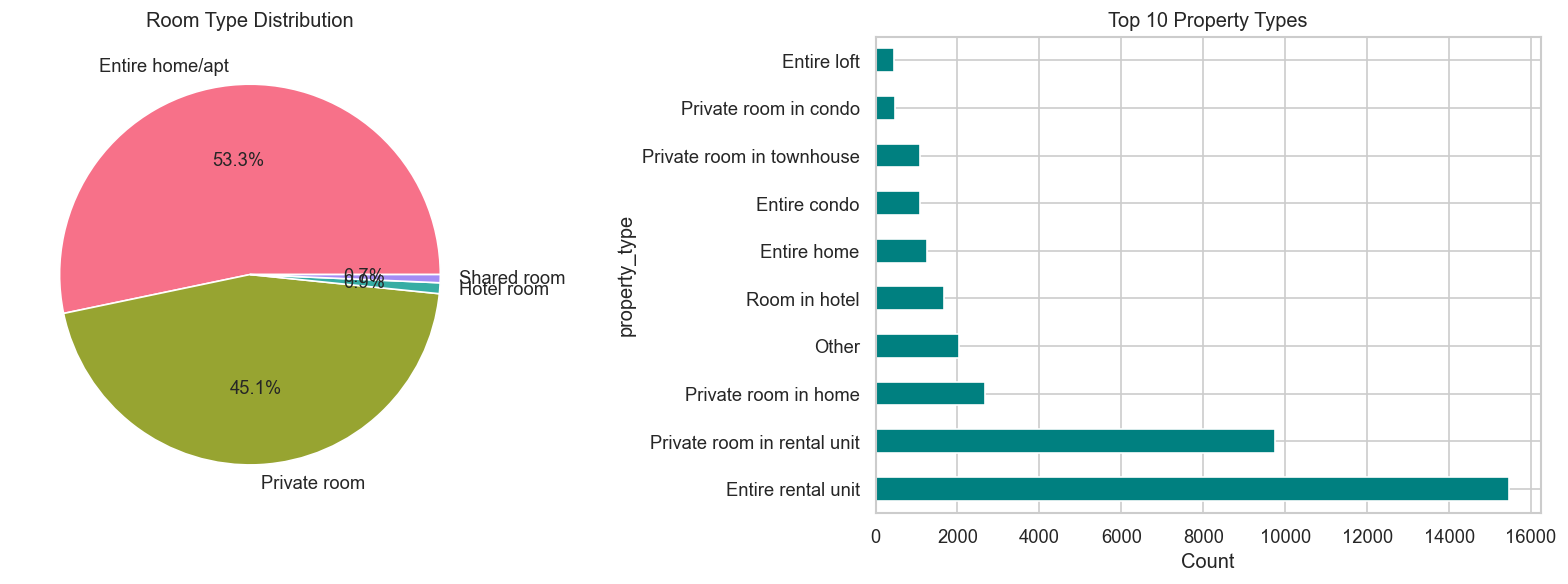

In [11]:
# ── 3.1 Room Type Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rt_counts = df['room_type'].value_counts()
axes[0].pie(rt_counts, labels=rt_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('husl', len(rt_counts)))
axes[0].set_title('Room Type Distribution')

df['property_type'].value_counts().nlargest(10).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 10 Property Types')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

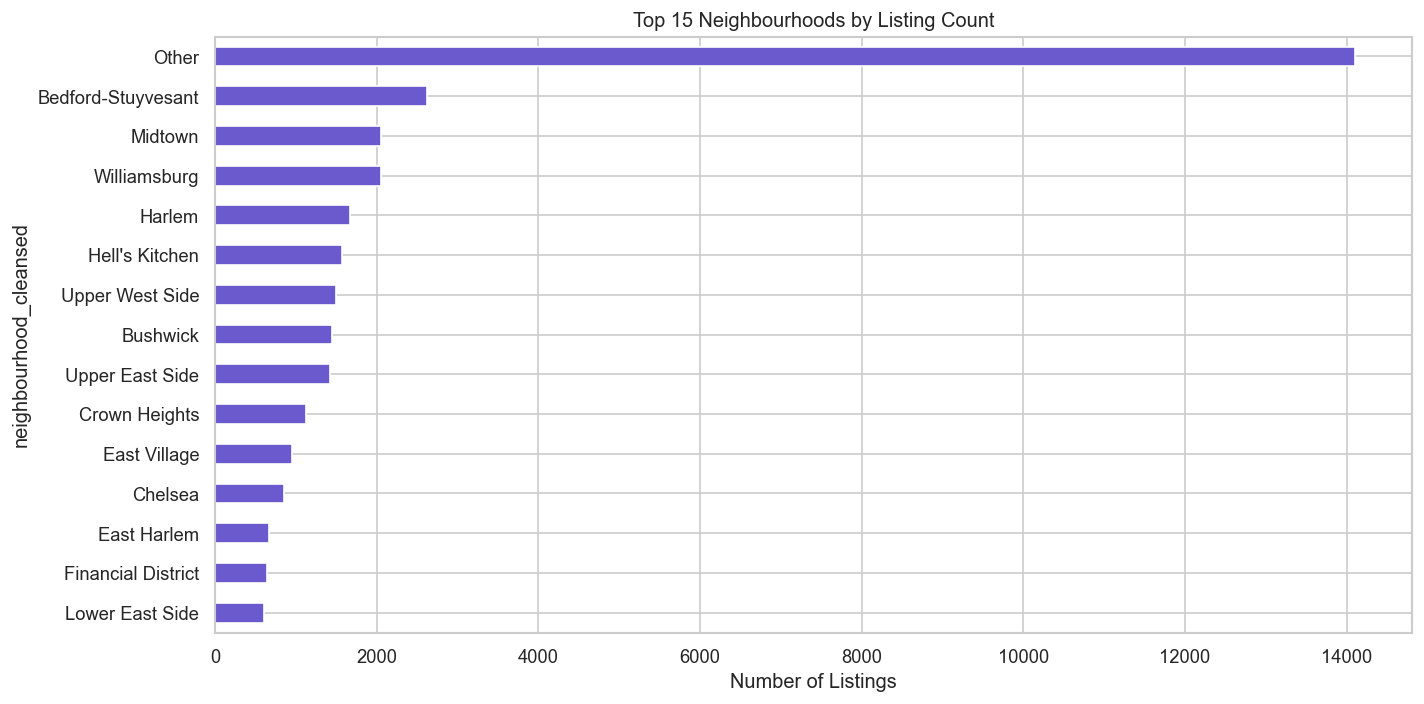

In [12]:
# ── 3.2 Top Neighbourhoods ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
df['neighbourhood_cleansed'].value_counts().nlargest(15).sort_values().plot(
    kind='barh', ax=ax, color='slateblue')
ax.set_title('Top 15 Neighbourhoods by Listing Count')
ax.set_xlabel('Number of Listings')
plt.tight_layout()
plt.show()

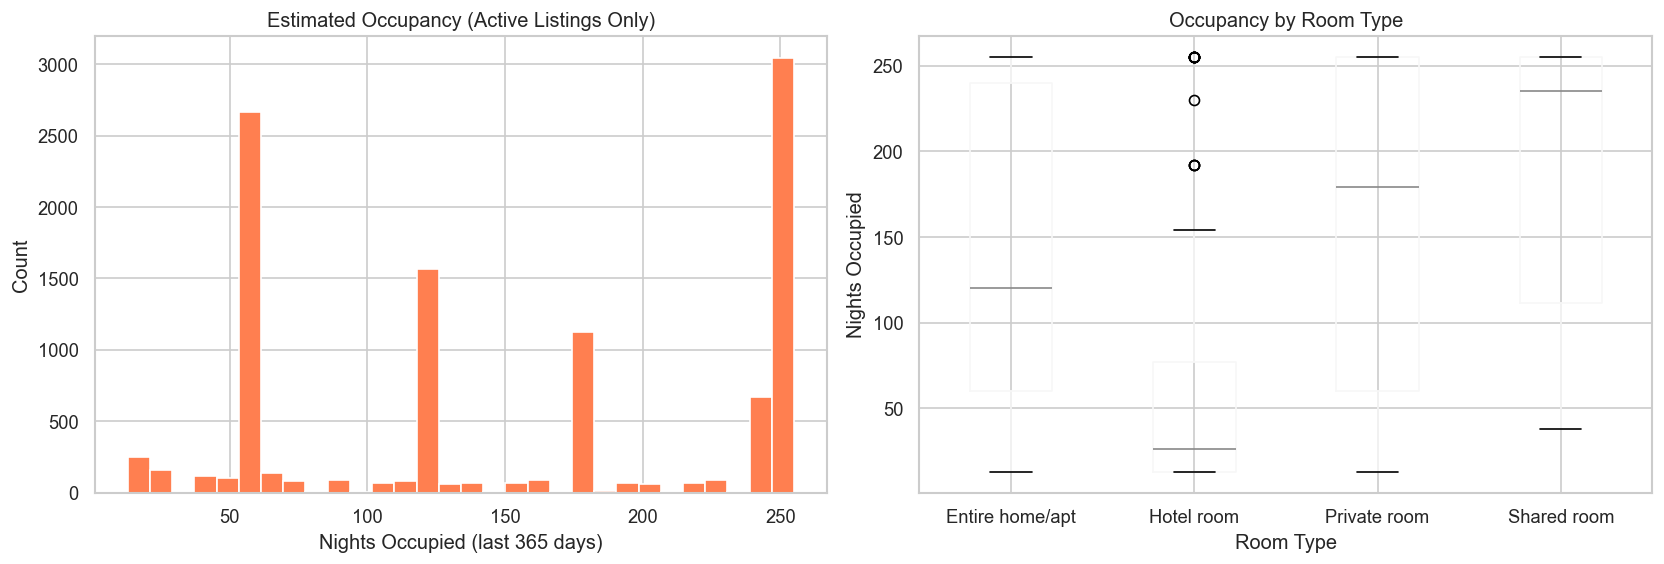

In [13]:
# ── 3.3 Occupancy Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

occ = df['estimated_occupancy_l365d']
axes[0].hist(occ[occ > 0], bins=30, color='coral', edgecolor='white')
axes[0].set_title('Estimated Occupancy (Active Listings Only)')
axes[0].set_xlabel('Nights Occupied (last 365 days)')
axes[0].set_ylabel('Count')

# Occupancy by room type
df[df['estimated_occupancy_l365d'] > 0].boxplot(
    column='estimated_occupancy_l365d', by='room_type', ax=axes[1]
)
axes[1].set_title('Occupancy by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Nights Occupied')
plt.suptitle('')
plt.tight_layout()
plt.show()

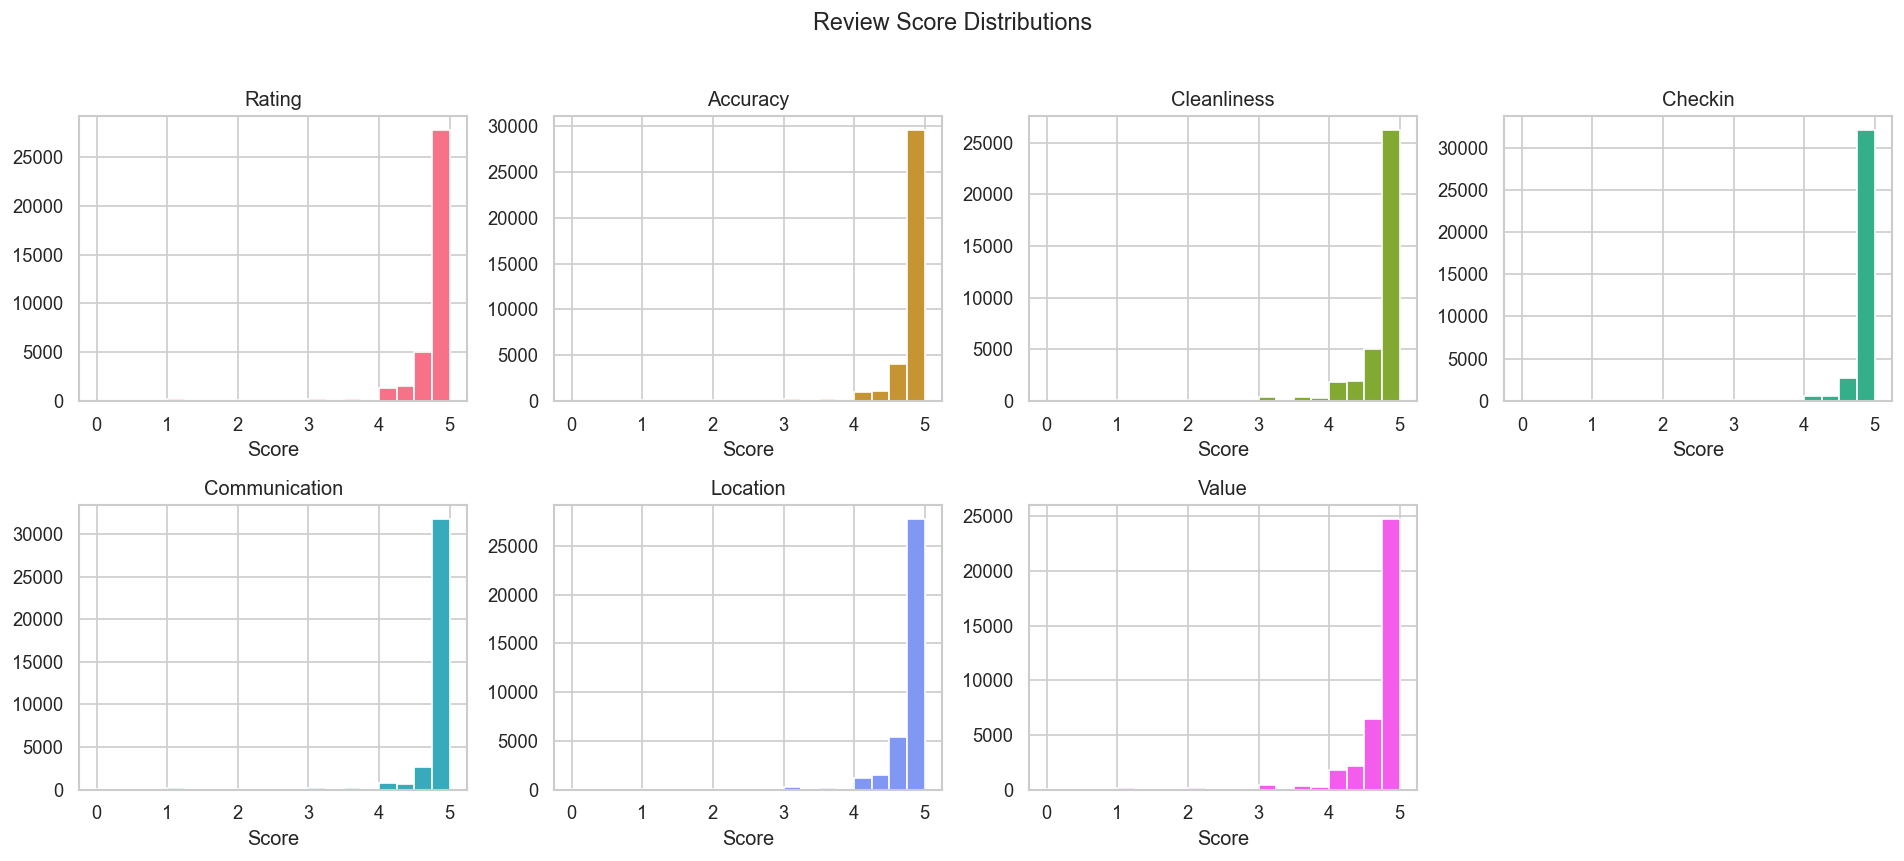

In [14]:
# ── 3.4 Review Scores Distribution ───────────────────────────────────────
review_cols = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]
review_cols = [c for c in review_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(review_cols):
    axes[i].hist(df[col].dropna(), bins=20, color=sns.color_palette('husl', 7)[i], edgecolor='white')
    axes[i].set_title(col.replace('review_scores_', '').title())
    axes[i].set_xlabel('Score')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Review Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

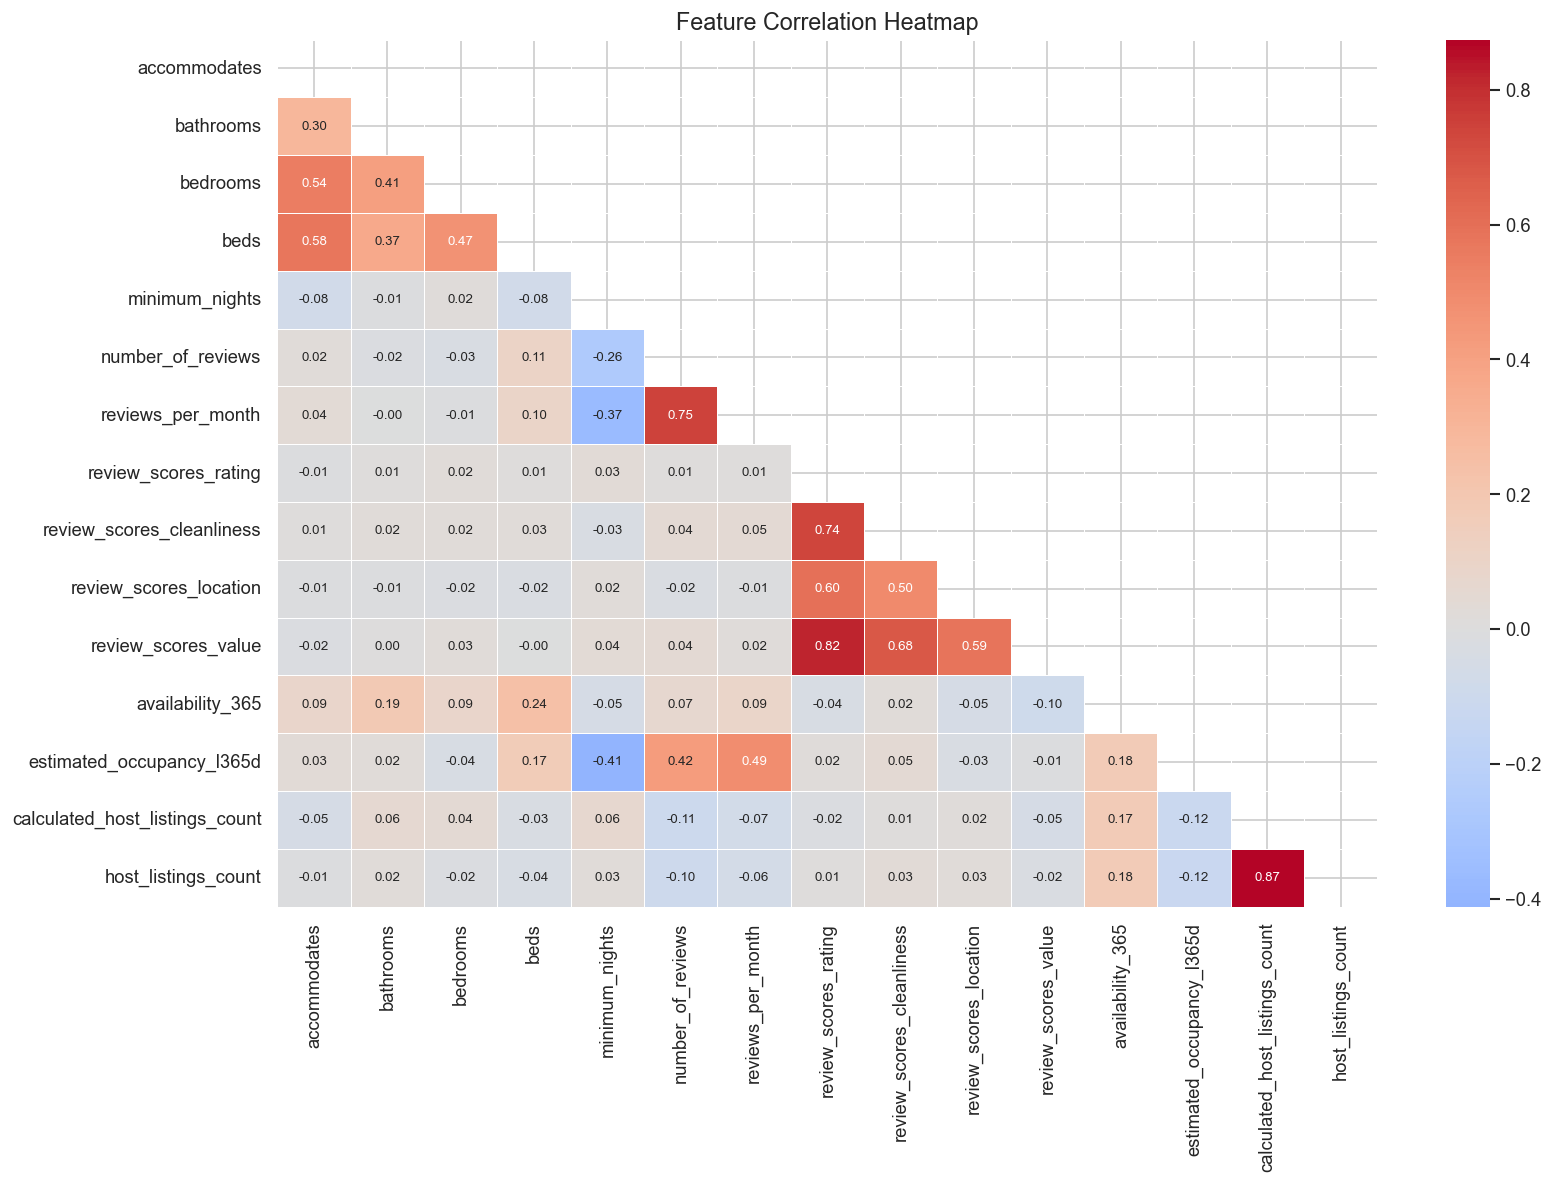

In [15]:
# ── 3.5 Correlation Heatmap ───────────────────────────────────────────────
corr_cols = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'availability_365', 'estimated_occupancy_l365d',
    'calculated_host_listings_count', 'host_listings_count'
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

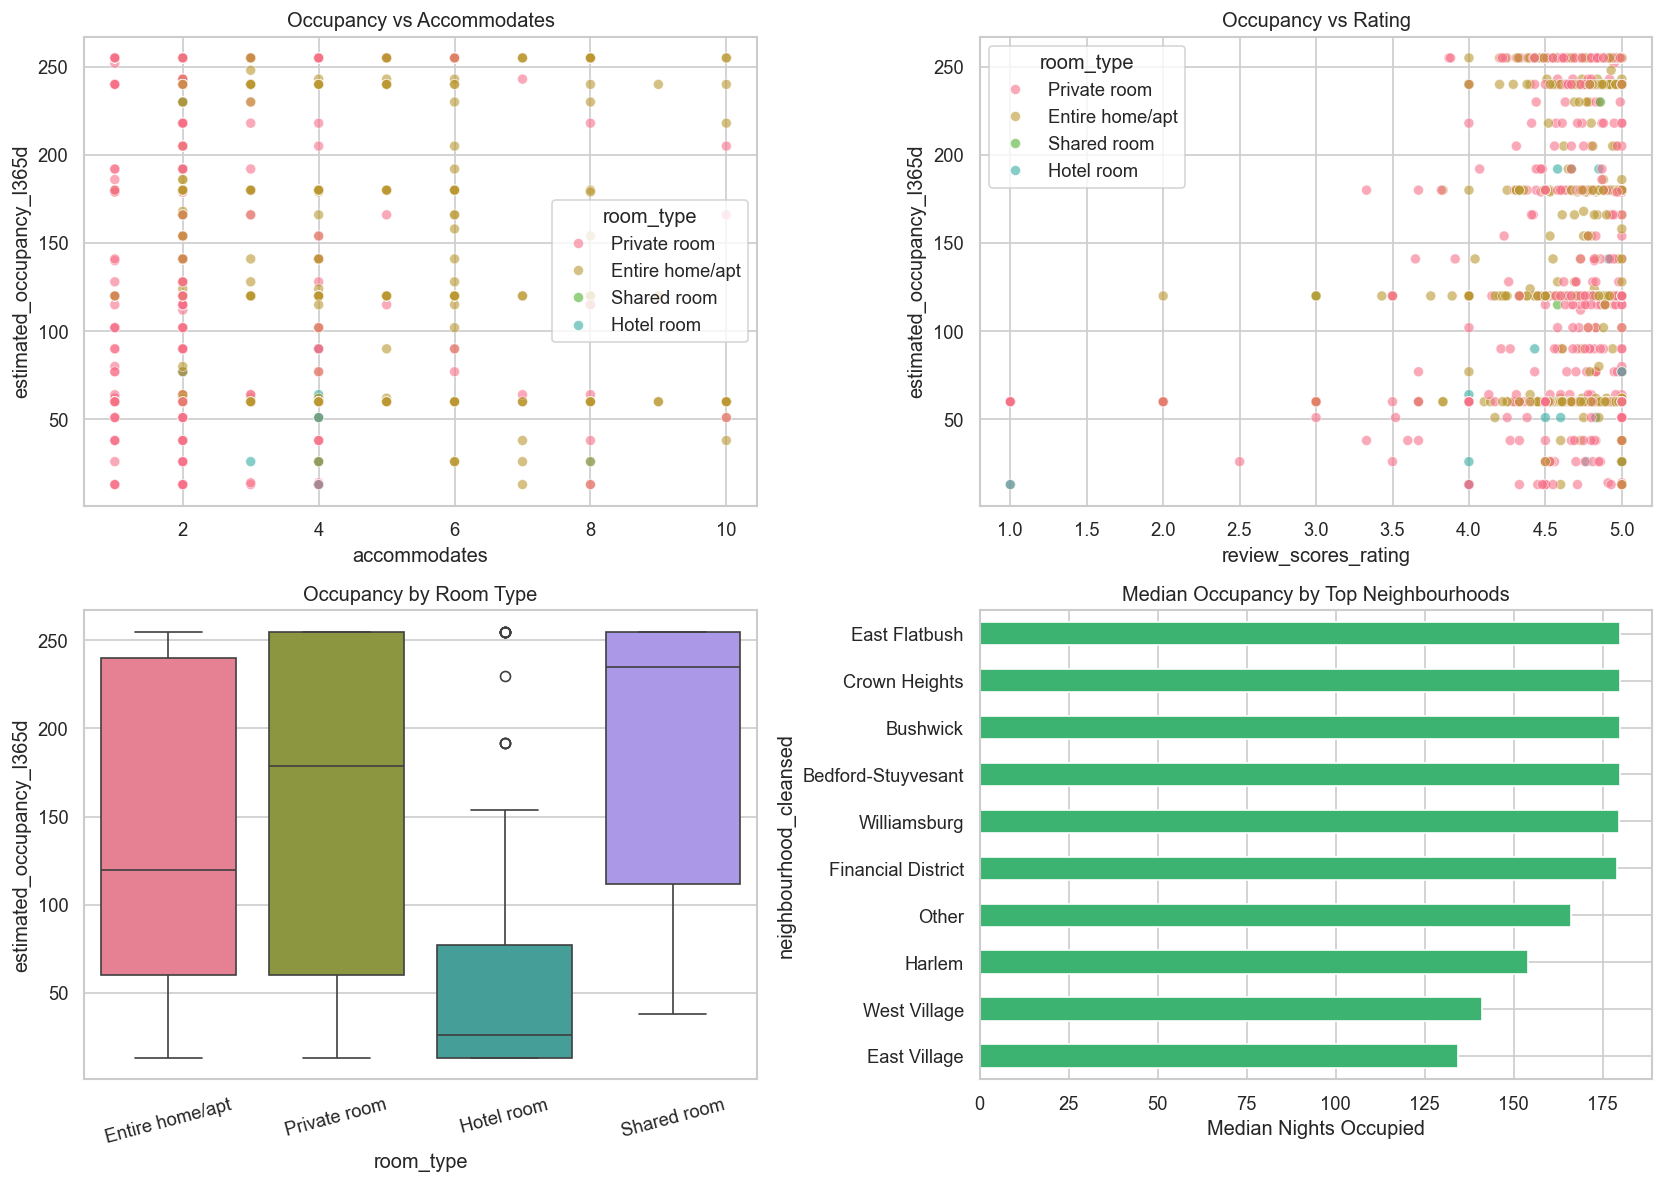

In [16]:
# ── 3.6 Occupancy vs Key Features ────────────────────────────────────────
df_active = df[df['estimated_occupancy_l365d'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_active.sample(min(2000, len(df_active)), random_state=SEED),
                x='accommodates', y='estimated_occupancy_l365d',
                hue='room_type', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Occupancy vs Accommodates')

sns.scatterplot(data=df_active.sample(min(2000, len(df_active)), random_state=SEED),
                x='review_scores_rating', y='estimated_occupancy_l365d',
                hue='room_type', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Occupancy vs Rating')

sns.boxplot(data=df_active, x='room_type', y='estimated_occupancy_l365d',
            palette='husl', ax=axes[1, 0])
axes[1, 0].set_title('Occupancy by Room Type')
axes[1, 0].tick_params(axis='x', rotation=15)

top_hoods_occ = df_active.groupby('neighbourhood_cleansed')['estimated_occupancy_l365d'].median().nlargest(10)
top_hoods_occ.sort_values().plot(kind='barh', ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('Median Occupancy by Top Neighbourhoods')
axes[1, 1].set_xlabel('Median Nights Occupied')

plt.tight_layout()
plt.show()

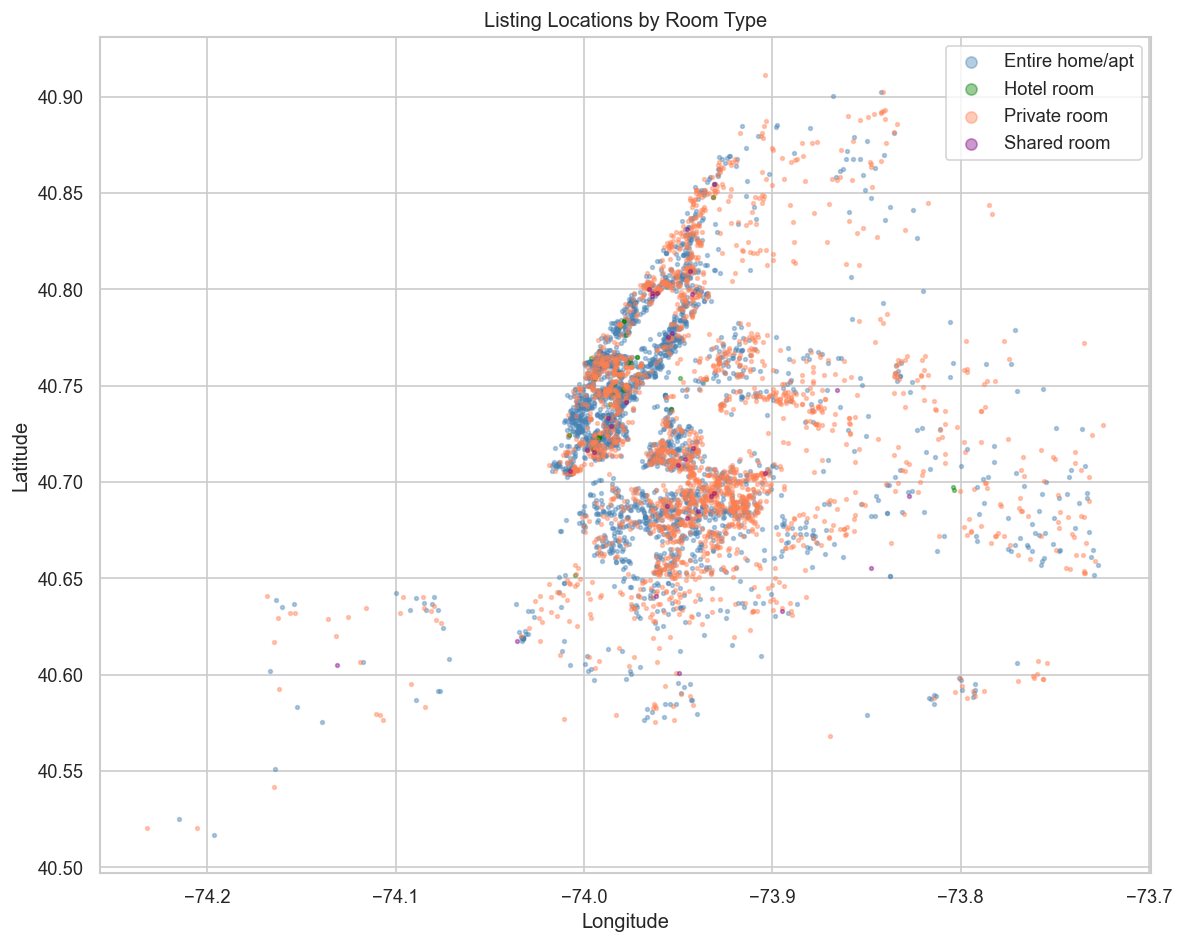

In [17]:
# ── 3.7 Geographic scatter of listings ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sample = df.sample(min(5000, len(df)), random_state=SEED)
colors = {'Entire home/apt': 'steelblue', 'Private room': 'coral',
          'Hotel room': 'green', 'Shared room': 'purple'}
for rt, grp in sample.groupby('room_type'):
    ax.scatter(grp['longitude'], grp['latitude'], label=rt,
               color=colors.get(rt, 'gray'), alpha=0.4, s=5)
ax.set_title('Listing Locations by Room Type')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering & Target Definition

In [18]:
df_ml = df.copy()

# ── Binary target: High Occupancy (>=60 nights/year = at least ~1 night/week avg) ──
df_ml['high_occupancy'] = (df_ml['estimated_occupancy_l365d'] >= 60).astype(int)
print('Target distribution:')
print(df_ml['high_occupancy'].value_counts())
print(f"Positive class rate: {df_ml['high_occupancy'].mean():.2%}")

Target distribution:
high_occupancy
0    26328
1    10117
Name: count, dtype: int64
Positive class rate: 27.76%


In [19]:
# ── Feature engineering ───────────────────────────────────────────────────
# Beds per person ratio
df_ml['beds_per_person'] = df_ml['beds'] / (df_ml['accommodates'] + 1e-5)

# Availability ratio
df_ml['availability_ratio'] = df_ml['availability_365'] / 365

# Review engagement score
df_ml['review_engagement'] = df_ml['reviews_per_month'].fillna(0) * df_ml['number_of_reviews']

# Label encode categoricals
le = LabelEncoder()
for col in ['room_type', 'property_type', 'neighbourhood_cleansed']:
    if col in df_ml.columns:
        df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))

print('Feature engineering complete.')

Feature engineering complete.


In [20]:
# ── Select final feature set ──────────────────────────────────────────────
FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'calculated_host_listings_count', 'host_listings_count',
    'latitude', 'longitude',
    'beds_per_person', 'availability_ratio', 'review_engagement',
    'room_type_enc', 'property_type_enc', 'neighbourhood_cleansed_enc',
    'hosts_time_as_host_years'
]
FEATURES = [f for f in FEATURES if f in df_ml.columns]
TARGET = 'high_occupancy'

X = df_ml[FEATURES].fillna(0)
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test positive rate:  {y_test.mean():.2%}')

Train: (29156, 31), Test: (7289, 31)
Train positive rate: 27.76%
Test positive rate:  27.75%


---
## 5. Model Training

In [21]:
# ── 5.1 Logistic Regression ───────────────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=SEED))
])
lr_pipe.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Low Occ', 'High Occ']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

     Low Occ       0.99      0.98      0.98      5266
    High Occ       0.95      0.97      0.96      2023

    accuracy                           0.98      7289
   macro avg       0.97      0.97      0.97      7289
weighted avg       0.98      0.98      0.98      7289

ROC-AUC: 0.9951


In [22]:
# ── 5.2 Random Forest ─────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Low Occ', 'High Occ']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

     Low Occ       1.00      1.00      1.00      5266
    High Occ       0.99      1.00      0.99      2023

    accuracy                           1.00      7289
   macro avg       0.99      1.00      1.00      7289
weighted avg       1.00      1.00      1.00      7289

ROC-AUC: 1.0000


In [23]:
# ── 5.3 Cross-validation comparison ──────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = {}
for name, model in [('Logistic Regression', lr_pipe), ('Random Forest', rf)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name} — CV F1: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression — CV F1: 0.9573 ± 0.0039
Random Forest — CV F1: 0.9913 ± 0.0017


---
## 6. Model Evaluation & Metrics

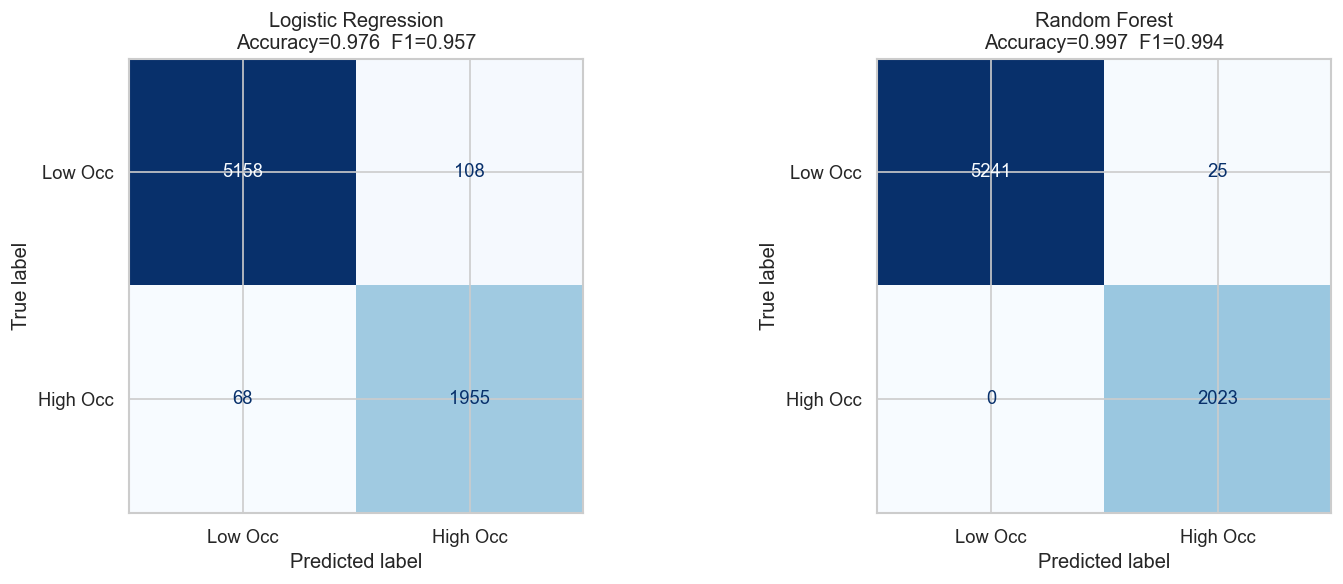

In [24]:
# ── 6.1 Confusion Matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, y_pred, model in [
    (axes[0], 'Logistic Regression', y_pred_lr, lr_pipe),
    (axes[1], 'Random Forest', y_pred_rf, rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low Occ', 'High Occ'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy={acc:.3f}  F1={f1:.3f}')

plt.tight_layout()
plt.show()

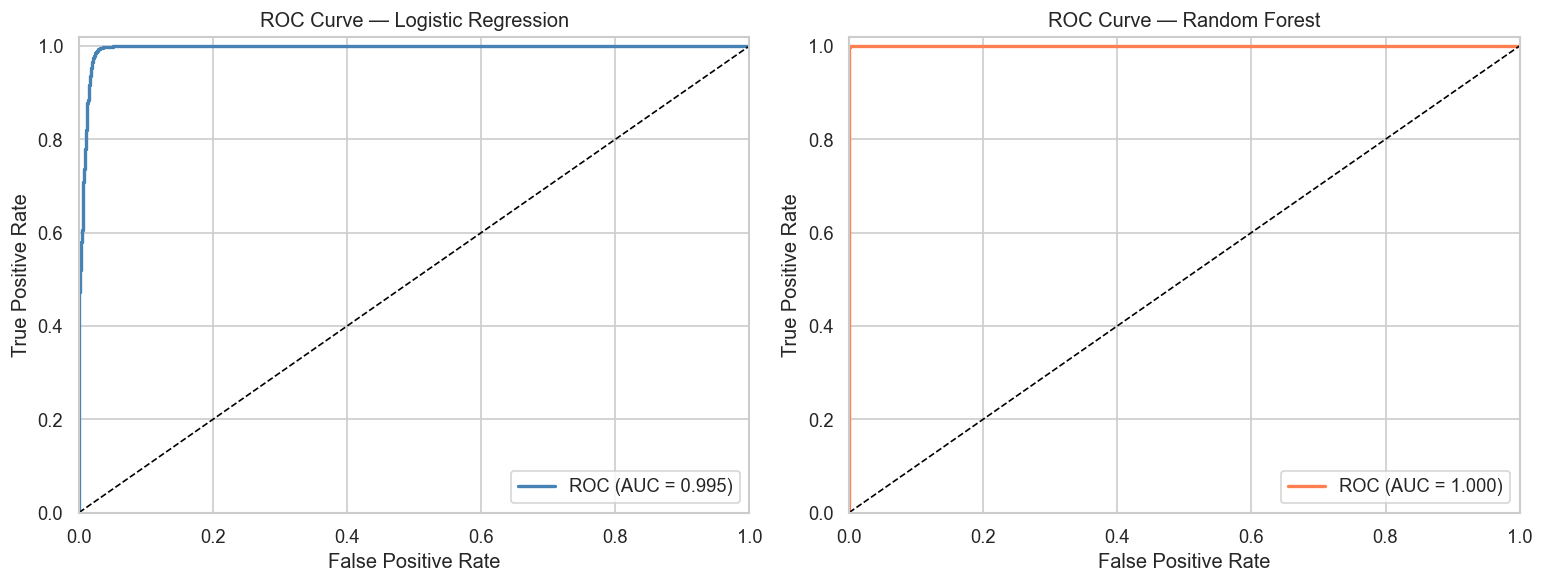

In [25]:
# ── 6.2 ROC Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, y_prob, color in [
    (axes[0], 'Logistic Regression', y_prob_lr, 'steelblue'),
    (axes[1], 'Random Forest', y_prob_rf, 'coral')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'ROC (AUC = {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

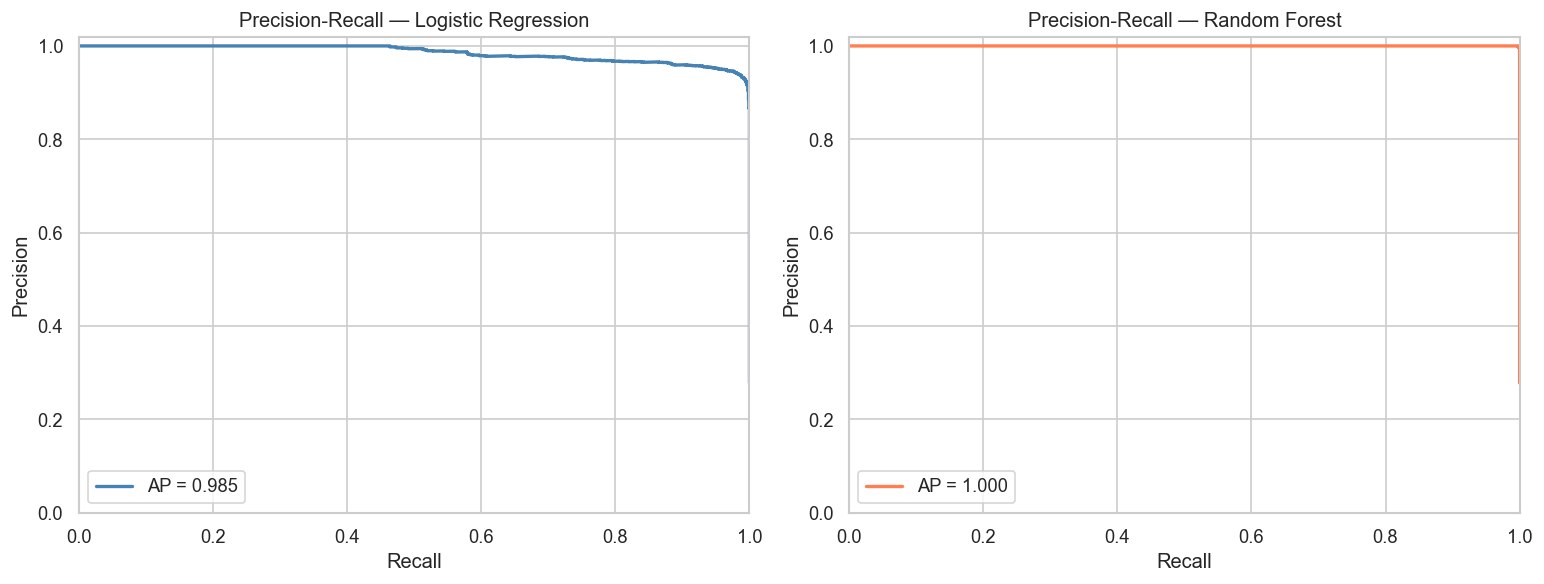

In [26]:
# ── 6.3 Precision-Recall Curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, y_prob, color in [
    (axes[0], 'Logistic Regression', y_prob_lr, 'steelblue'),
    (axes[1], 'Random Forest', y_prob_rf, 'coral')
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, lw=2, label=f'AP = {ap:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall — {name}')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

In [27]:
# ── 6.4 Metrics Summary Table ────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

results = []
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Random Forest', y_pred_rf, y_prob_rf),
]:
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 (macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 (pos class)': round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Avg Precision': round(average_precision_score(y_test, y_prob), 4),
    })

metrics_df = pd.DataFrame(results).set_index('Model')
metrics_df.style.highlight_max(color='lightgreen').format('{:.4f}')

,Accuracy,F1 (macro),F1 (pos class),Precision,Recall,ROC-AUC,Avg Precision
Model,,,,,,,
Logistic Regression,0.9759,0.9701,0.9569,0.9476,0.9664,0.9951,0.9849
Random Forest,0.9966,0.9957,0.9939,0.9878,1.0000,1.0000,1.0000


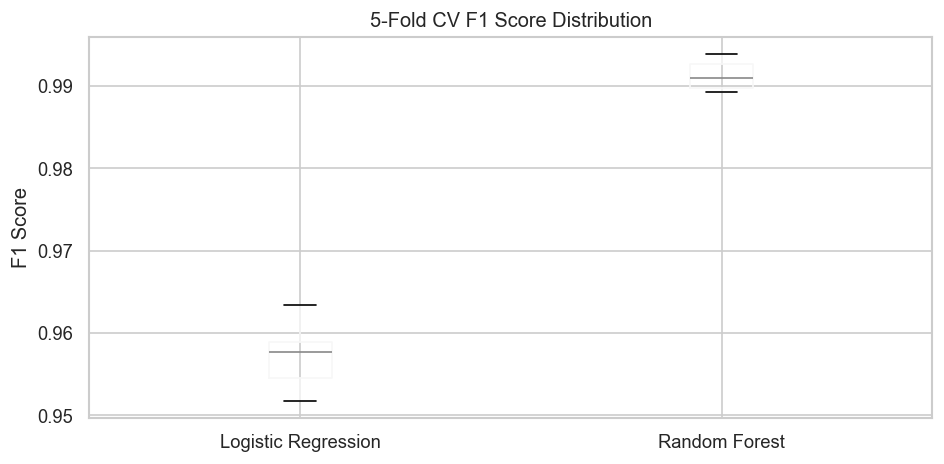

In [28]:
# ── 6.5 CV Score Distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
cv_df = pd.DataFrame(cv_scores)
cv_df.boxplot(ax=ax)
ax.set_title('5-Fold CV F1 Score Distribution')
ax.set_ylabel('F1 Score')
plt.tight_layout()
plt.show()

---
## 7. Feature Importance & Key Drivers

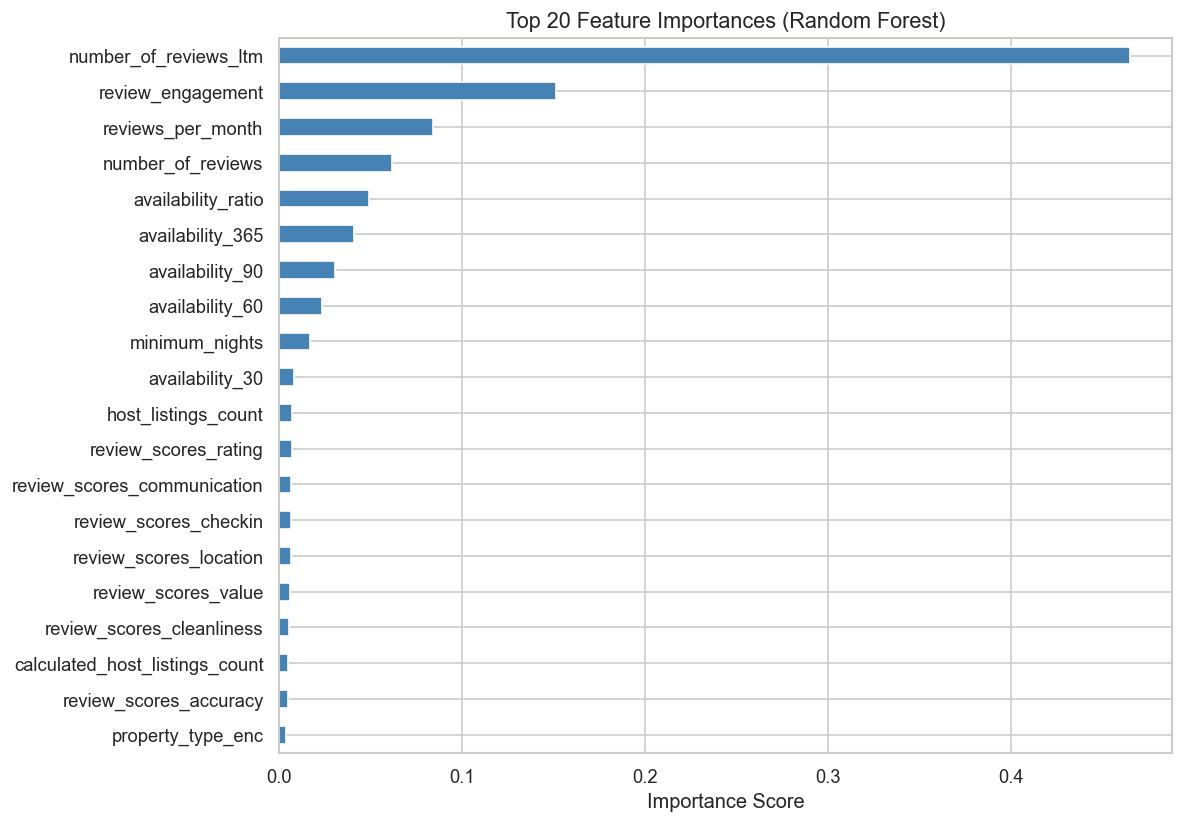


Top 10 features:
number_of_reviews_ltm    0.465058
review_engagement        0.151382
reviews_per_month        0.083895
number_of_reviews        0.061804
availability_ratio       0.049181
availability_365         0.040763
availability_90          0.030206
availability_60          0.023187
minimum_nights           0.016913
availability_30          0.007864


In [29]:
# ── 7.1 Random Forest Feature Importance ────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances_sorted = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances_sorted.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(importances_sorted.head(10).to_string())

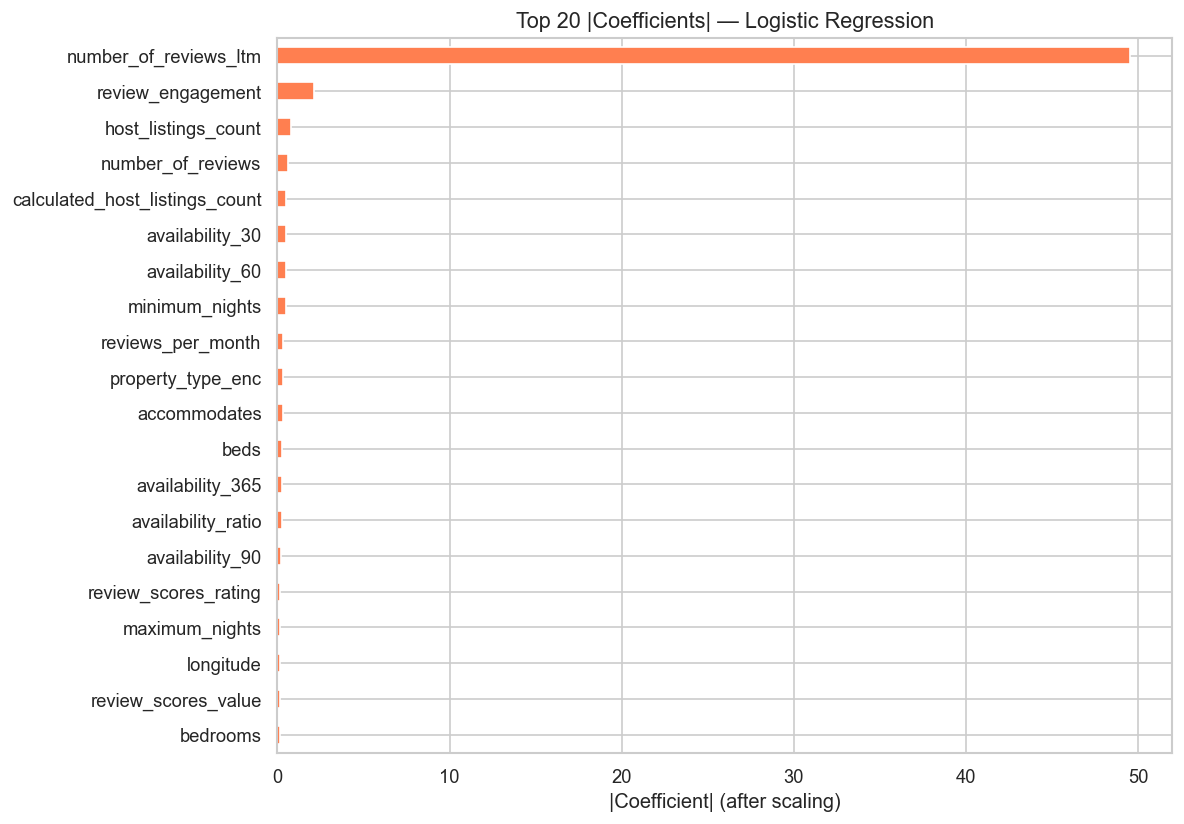

In [30]:
# ── 7.2 Logistic Regression Coefficients ─────────────────────────────────
lr_coefs = pd.Series(
    lr_pipe.named_steps['clf'].coef_[0],
    index=FEATURES
).abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
lr_coefs.sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 |Coefficients| — Logistic Regression', fontsize=13)
ax.set_xlabel('|Coefficient| (after scaling)')
plt.tight_layout()
plt.show()

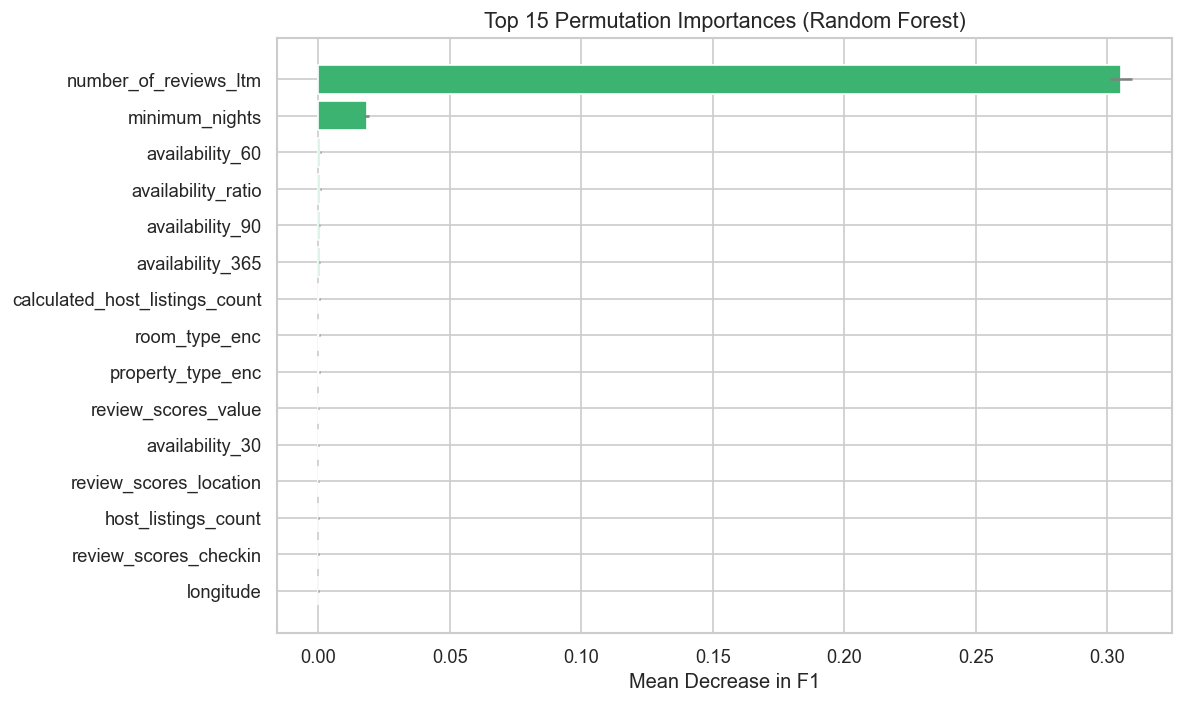

In [31]:
# ── 7.3 Permutation Importance (model-agnostic) ──────────────────────────
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=SEED, n_jobs=-1)
perm_imp = pd.DataFrame({'mean': perm.importances_mean, 'std': perm.importances_std}, index=FEATURES)
perm_imp = perm_imp.sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_imp.index[::-1], perm_imp['mean'][::-1],
        xerr=perm_imp['std'][::-1], color='mediumseagreen', ecolor='gray')
ax.set_title('Top 15 Permutation Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Mean Decrease in F1')
plt.tight_layout()
plt.show()

---
## 8. Business Insights — What Drives Airbnb Performance?

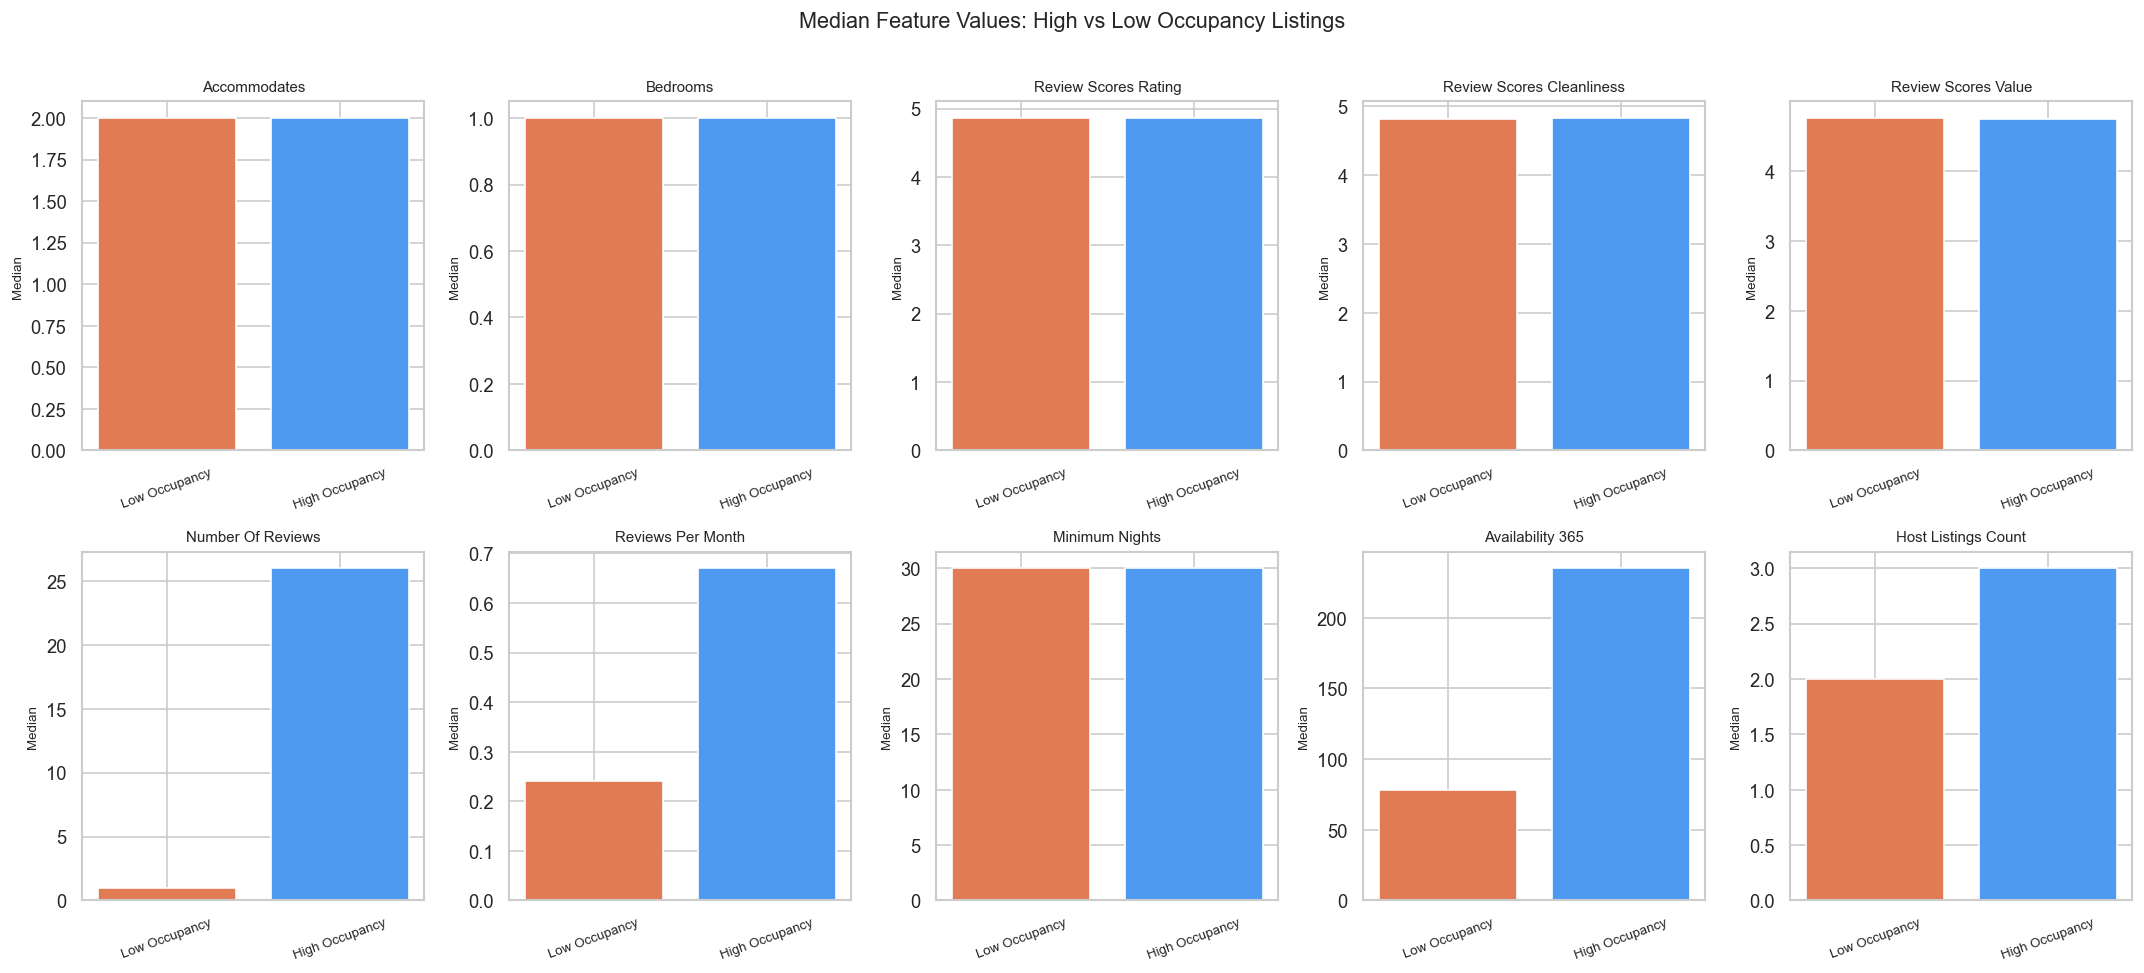

                           Low Occupancy  High Occupancy
accommodates                        2.00            2.00
bedrooms                            1.00            1.00
review_scores_rating                4.86            4.86
review_scores_cleanliness           4.82            4.83
review_scores_value                 4.76            4.75
number_of_reviews                   1.00           26.00
reviews_per_month                   0.24            0.67
minimum_nights                     30.00           30.00
availability_365                   78.00          235.00
host_listings_count                 2.00            3.00


In [32]:
# ── 8.1 High vs Low occupancy — profile comparison ───────────────────────
compare_cols = [
    'accommodates', 'bedrooms', 'review_scores_rating',
    'review_scores_cleanliness', 'review_scores_value',
    'number_of_reviews', 'reviews_per_month', 'minimum_nights',
    'availability_365', 'host_listings_count'
]
compare_cols = [c for c in compare_cols if c in df_ml.columns]

profile = df_ml.groupby('high_occupancy')[compare_cols].median()
profile.index = ['Low Occupancy', 'High Occupancy']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
colors = ['#E07B54', '#4E9AF1']

for i, col in enumerate(compare_cols[:10]):
    axes[i].bar(profile.index, profile[col], color=colors)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].tick_params(axis='x', rotation=20, labelsize=8)
    axes[i].set_ylabel('Median', fontsize=8)

fig.suptitle('Median Feature Values: High vs Low Occupancy Listings', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print(profile.T.to_string())

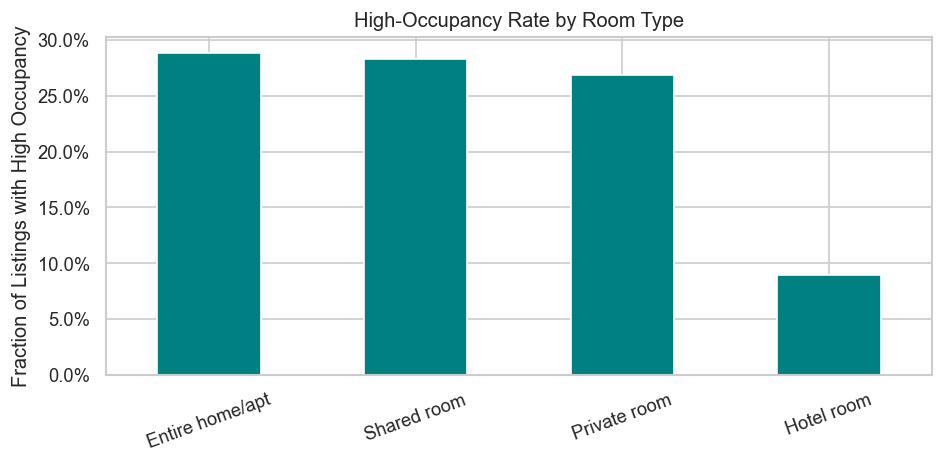

In [33]:
# ── 8.2 Room type × occupancy rate ───────────────────────────────────────
rt_occ = df_ml.groupby('room_type')['high_occupancy'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
rt_occ.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('High-Occupancy Rate by Room Type')
ax.set_ylabel('Fraction of Listings with High Occupancy')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

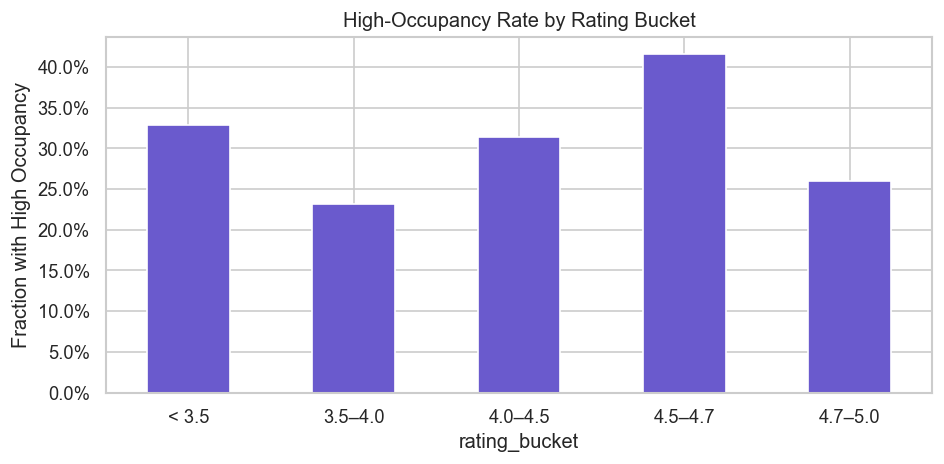

In [34]:
# ── 8.3 Rating buckets × occupancy ───────────────────────────────────────
df_ml['rating_bucket'] = pd.cut(
    df_ml['review_scores_rating'],
    bins=[0, 3.5, 4.0, 4.5, 4.7, 5.0],
    labels=['< 3.5', '3.5–4.0', '4.0–4.5', '4.5–4.7', '4.7–5.0']
)
rating_occ = df_ml.groupby('rating_bucket', observed=False)['high_occupancy'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
rating_occ.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('High-Occupancy Rate by Rating Bucket')
ax.set_ylabel('Fraction with High Occupancy')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# ── 8.4 Neighbourhood performance ────────────────────────────────────────
hood_stats = df_ml.groupby('neighbourhood_cleansed').agg(
    listings=('high_occupancy', 'count'),
    high_occ_rate=('high_occupancy', 'mean'),
    median_occupancy=('estimated_occupancy_l365d', 'median')
).sort_values('high_occ_rate', ascending=False)

print('Neighbourhood Performance (Top 15 by High Occ Rate):')
hood_stats.head(15).style.format({'high_occ_rate': '{:.1%}', 'median_occupancy': '{:.0f}'})

Neighbourhood Performance (Top 15 by High Occ Rate):


,listings,high_occ_rate,median_occupancy
neighbourhood_cleansed,,,
East Flatbush,523,37.7%,0
Upper East Side,1427,31.5%,0
Hell's Kitchen,1565,30.6%,0
Other,14106,30.4%,0
Chelsea,849,30.4%,0
Crown Heights,1129,30.1%,0
Harlem,1676,30.1%,0
East Harlem,669,29.6%,0
Bedford-Stuyvesant,2621,28.7%,0
